1) Histogram equalization
Histogram equalization is a method in image processing of contrast adjustment using
the image’s histogram.
This method usually increases the global contrast of many images, especially when
the usable data of the image is represented by close contrast values. Through this
adjustment, the intensities can be better distributed on the histogram. This allows for
areas of lower local contrast to gain a higher contrast. Histogram equalization
accomplishes this by effectively spreading out the most frequent intensity values. The
method is useful in images with backgrounds and foregrounds that are both bright or
both dark.
OpenCV has a function to do this, cv2.equalizeHist(). Its input is just grayscale image
and output is our histogram equalized image.

In [14]:
import cv2
import numpy as np
img = cv2.imread('astronaut.jpg',0)
equ = cv2.equalizeHist(img)
res = np.hstack((img, equ))
cv2.imshow('image', res)
cv2.waitKey(0)
cv2.destroyAllWindows()

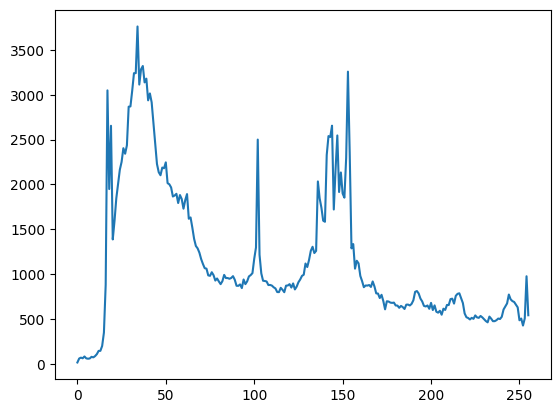

In [4]:
import cv2
from matplotlib import pyplot as plt
img = cv2.imread('landscape.jpg')
image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY )
histr = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(histr)
plt.show()

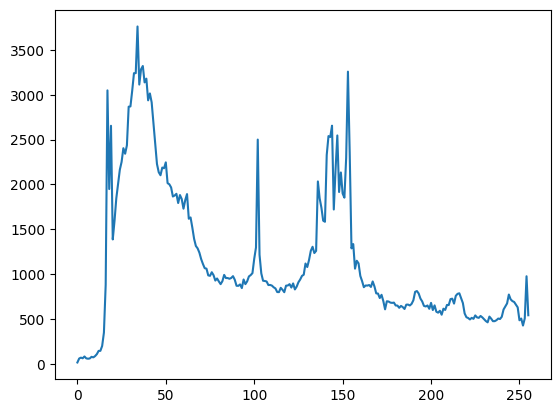

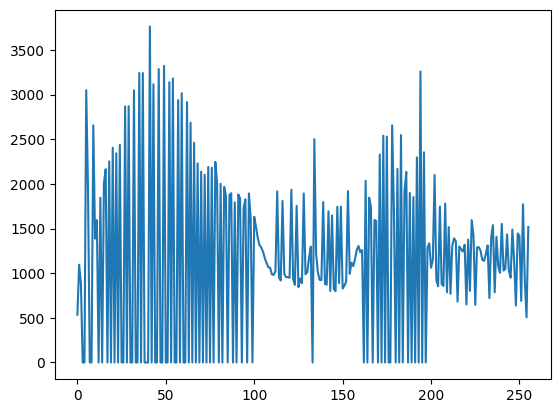

-1

In [5]:
import cv2
from matplotlib import pyplot as plt
import matplotlib.image as img
import numpy as np
img = cv2.imread('landscape.jpg')
image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY )
equ = cv2.equalizeHist(image)
res = np.hstack((image, equ))
histr1 = cv2.calcHist([image],[0],None,[256],[0,256])
histr = cv2.calcHist([equ],[0],None,[256],[0,256])
plt.plot(histr1)
plt.show()
plt.plot(histr)
plt.show()
cv2.imshow('image', res)
cv2.waitKey(0)

2) Histogram matching
Histogram matching is used for normalizing the representation of images, it can be
used for feature matching, especially when the pictures are from diverse sources or
under varied conditions (depending on the light, etc). each image has a number of
channels, each channel is matched individually. Histogram matching is possible only
if the number of channels matches in the input and reference images.
.
match_histograms() method:
This method is used to modify the cumulative histogram of one picture to match the
histogram of another. For each channel, the modification is made independently.
Syntax: skimage.exposure.match_histograms(image, reference, *,
channel_axis=None, multichannel=False)

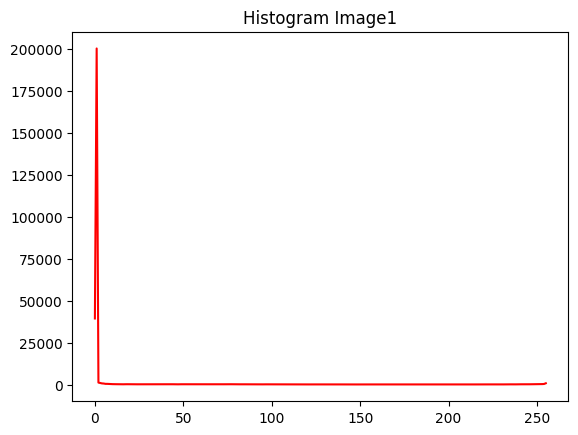

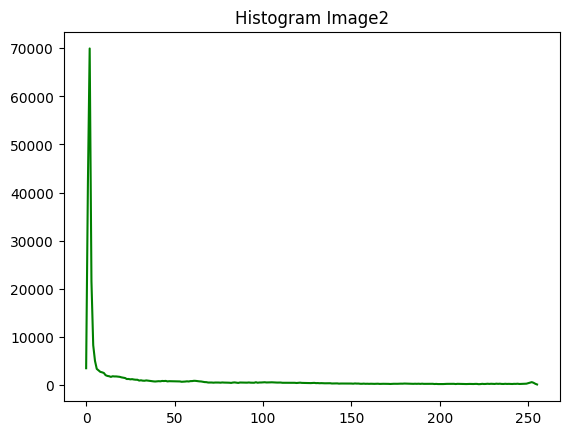

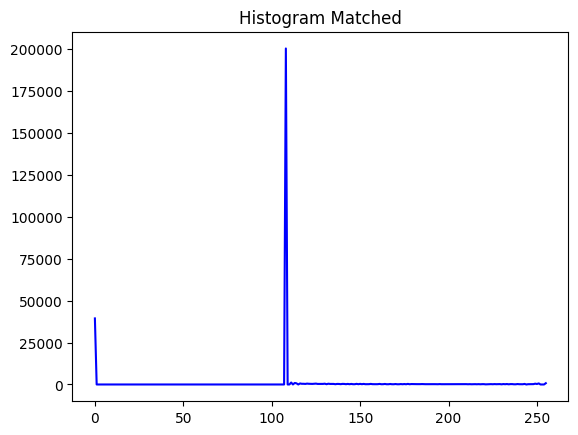

In [11]:
import cv2
from matplotlib import pyplot as plt
from skimage import exposure
import numpy as np

# Read images
img1 = cv2.imread('astronaut.jpg')
img2 = cv2.imread('Space.jpg')

# Convert from BGR to RGB for histogram matching
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Resize img2 to match img1's size
img2_resized = cv2.resize(img2_rgb, (img1_rgb.shape[1], img1_rgb.shape[0]))

# Histogram matching
matched = exposure.match_histograms(img1_rgb, img2_resized, channel_axis=-1)

# Compute histograms
histr = cv2.calcHist([img1_rgb],[0],None,[256],[0,256])
histr1 = cv2.calcHist([img2_resized],[0],None,[256],[0,256])
histr2 = cv2.calcHist([matched.astype(np.uint8)],[0],None,[256],[0,256])

# Plot histograms
plt.plot(histr, color='r'); plt.title("Histogram Image1"); plt.show()
plt.plot(histr1, color='g'); plt.title("Histogram Image2"); plt.show()
plt.plot(histr2, color='b'); plt.title("Histogram Matched"); plt.show()

# Display results side by side
res = np.hstack((img1_rgb, img2_resized, matched.astype(np.uint8)))
cv2.imshow('result', cv2.cvtColor(res, cv2.COLOR_RGB2BGR))
cv2.waitKey(0)
cv2.destroyAllWindows()


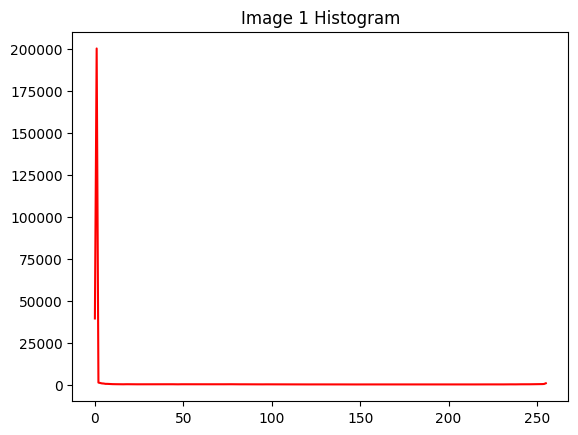

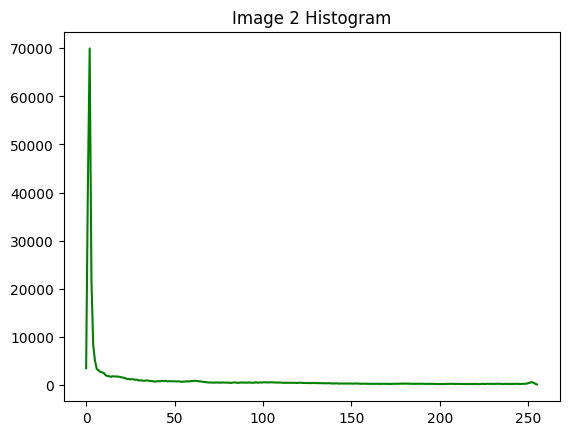

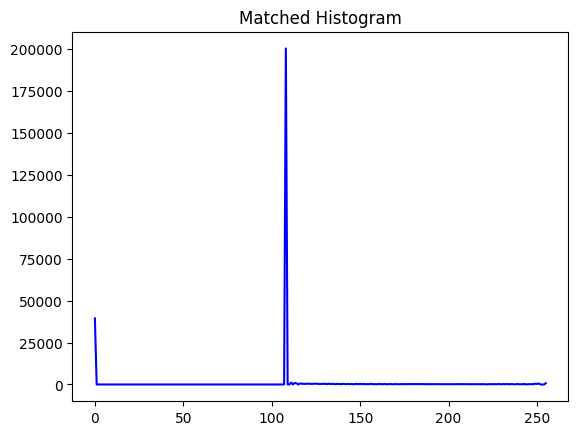

In [13]:
import cv2
from matplotlib import pyplot as plt
from skimage import exposure
import numpy as np

# Read images
img1 = cv2.imread('astronaut.jpg')
img2 = cv2.imread('Space.jpg')

# Convert BGR → RGB
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Resize img2 to match img1 shape
img2_resized = cv2.resize(img2_rgb, (img1_rgb.shape[1], img1_rgb.shape[0]))

# Histogram matching
matched = exposure.match_histograms(img1_rgb, img2_resized, channel_axis=-1)

# Compute histograms
histr  = cv2.calcHist([img1_rgb],[0],None,[256],[0,256])
histr1 = cv2.calcHist([img2_resized],[0],None,[256],[0,256])
histr2 = cv2.calcHist([matched.astype(np.uint8)],[0],None,[256],[0,256])

# Plot histograms
plt.plot(histr, color='r'); plt.title("Image 1 Histogram"); plt.show()
plt.plot(histr1, color='g'); plt.title("Image 2 Histogram"); plt.show()
plt.plot(histr2, color='b'); plt.title("Matched Histogram"); plt.show()

# Stack and display results
res = np.hstack((img1_rgb, img2_resized, matched.astype(np.uint8)))
cv2.imshow('result', cv2.cvtColor(res, cv2.COLOR_RGB2BGR))
cv2.waitKey(0)
cv2.destroyAllWindows()
